### Cuadro Comparativo: SRTM vs OpenTopography

| Criterio | SRTM (NASA) | OpenTopography |
| :--- | :--- | :--- |
| **Resolución** | 30 m (1 arc-sec) o 90 m (3 arc-sec) | Variable (desde 1m hasta 30m según el sensor) |
| **Acceso API / Descarga** | Gratuito y directo vía Earthdata / USGS | Requiere API Key y depende de la cuota diaria |
| **Homogeneidad** | Homogéneo en todo Sudamérica | Variable según la zona o proveedor |
| **Integración con Autómata** | Grilla uniforme (3601x3601 o 1201x1201) | Requiere reproyección y remuestreo previo |

> **Conclusión:** SRTM Garantiza grillas continuas, consumo de RAM ligero (~25 MB por cuadrícula) y fácil conversión a arreglos NumPy.

In [ ]:
!pip install elevation rasterio numpy matplotlib -q
import os
import elevation
#libreria elevation, libreria del SRTM(NASA) para interactuar desde el python.
#libreria rasterio: Para leer y escribir archivos GIS (Sistemas de Información Geográfica)
coordenadas_pucallpa=(-74.65, -8.45, -74.45, -8.30)## sacas en https://bboxfinder.com/#0.000000,0.000000,0.000000,0.000000
ruta_dem  = os.path.join(os.getcwd(),'Pucallpa_SRTM_30m.tif') #Le decimos dónde guardar el archivo en nuestra máquina de Colab
elevation.clip(bounds = coordenadas_pucallpa,output=ruta_dem)

Metadatos del DEM
Ancho:  720 || altura:  540
Sistema de Coordenadas:  EPSG:4326
Valor basura de la NASA (NoData):  -32768.0


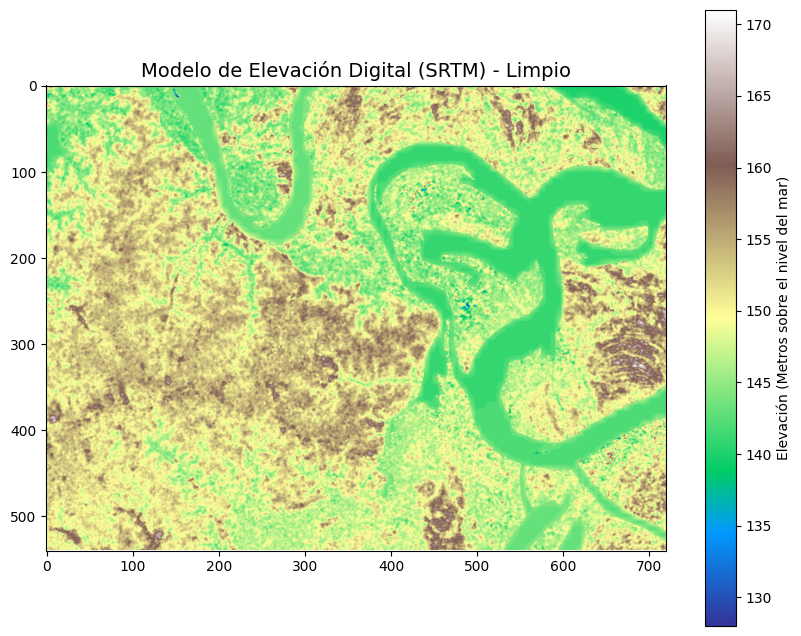

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
with rasterio.open(ruta_dem) as dataset:
  # Leemos la matriz de datos (La banda 1 tiene la altura)
    matriz_elevacion = dataset.read(1)
    nodata_value = dataset.nodata
    print("Metadatos del DEM")
    print("Ancho: ",dataset.width, "|| altura: ",dataset.height)
    print("Sistema de Coordenadas: ",dataset.crs)
    print("Valor basura de la NASA (NoData): ",nodata_value)
    matriz_limpia = matriz_elevacion.astype(float)
    if nodata_value is not None:
      matriz_limpia[matriz_limpia == nodata_value]=np.nan
##Visualizamos la matriz limpia
plt.figure(figsize=(10, 8))
imagen = plt.imshow(matriz_limpia, cmap='terrain')
plt.colorbar(imagen, label="Elevación (Metros sobre el nivel del mar)")
plt.title("Modelo de Elevación Digital (SRTM) - Limpio", fontsize=14)
plt.show()

***## La gradiente espacial es la derivada del terreno, para detectar como se dispersa el fuego, ya que si no va a suponer que todo es llano.***

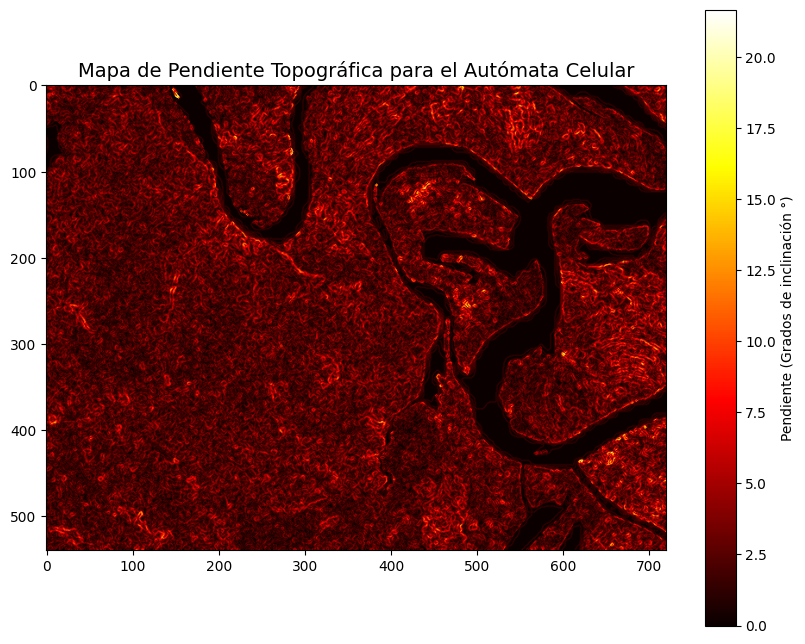

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# La resolución espacial del SRTM es de ~30 metros por cada píxel
resolucion_metros = 30.0
# np.gradient calcula la derivada: ¿Cuánto cambia la altura al movernos a la celda vecina?
# Genera el cambio en el eje Y (Norte-Sur) y en el eje X (Este-Oeste)
gradiente_y, gradiente_x = np.gradient(matriz_limpia, resolucion_metros, resolucion_metros)

#   Teorema de Pitágoras para hallar la magnitud total de la inclinación
pendiente_magnitud = np.sqrt(gradiente_x**2 + gradiente_y**2)

#   Convertimos la magnitud a Grados exactos (0° a 90°) usando arco tangente
matriz_pendiente_grados = np.degrees(np.arctan(pendiente_magnitud))

# 5. Visualizamos la matriz final de pendientes
plt.figure(figsize=(10, 8))
# Usamos 'hot' para representar el nivel de peligro (inclinación) para el fuego
imagen_pendiente = plt.imshow(matriz_pendiente_grados, cmap='hot')
plt.colorbar(imagen_pendiente, label="Pendiente (Grados de inclinación °)")
plt.title("Mapa de Pendiente Topográfica para el Autómata Celular", fontsize=14)
plt.show()